In [40]:
import sympy as sp

In [154]:
x = sp.symbols('x')
u, u_0, phi, u_hat, eta, eta_0, eta_hat, psi, H = sp.symbols(r"u u_0 \varphi \hat{u} \eta \eta_0 \hat{\eta} \psi H", cls=sp.Function)
Delta_t, theta, nu, g, epsilon = sp.symbols(r"\Delta_t \theta \nu g \varepsilon")

# Define the derivatives
u_prime = sp.diff(u(x), x)
u_prime_prime = sp.diff(u_prime, x)
u_0prime = sp.diff(u_0(x),x)
u_0prime_prime = sp.diff(u_0prime, x)
eta_prime = sp.diff(eta(x), x)
eta_0prime = sp.diff(eta_0(x),x)
psi_prime = sp.diff(psi(x), x)
phi_prime = sp.diff(phi(x), x)
H_prime = sp.diff(H(x), x)

F_1 = (
    (1/Delta_t)*(u(x) - u_0(x)) + 
    (u(x)*u_prime) +
    g*(eta_prime) -
    nu*u_prime_prime
)

F_2 = (
    (1/Delta_t)*(eta(x) - eta_0(x)) + 
    (H_prime + eta_prime)*u(x) +
    (H(x) + eta(x))*u_prime
)

u_perturbed = u(x) + epsilon * u_hat(x)
u_perturbed_prime = sp.diff(u_perturbed, x)
u_perturbed_prime_prime = sp.diff(u_perturbed_prime, x)

eta_perturbed = eta(x) + epsilon * eta_hat(x)
eta_perturbed_prime = sp.diff(eta_perturbed, x)

F_1_perturbed = (
    (1/Delta_t)*(u_perturbed - u_0(x)) + 
    (u_perturbed*u_perturbed_prime) +
    g*(eta_perturbed_prime) -
    nu*u_perturbed_prime_prime
)

F_2_perturbed = (
    (1/Delta_t)*(eta_perturbed - eta_0(x)) + 
    (H_prime + eta_perturbed_prime)*u_perturbed +
    (H(x) + eta_perturbed)*u_perturbed_prime
)

jacobian_1 = sp.limit((F_1_perturbed - F_1) / epsilon, epsilon, 0)
jacobian_2 = sp.limit((F_2_perturbed - F_2) / epsilon, epsilon, 0)

In [1]:
import sympy as sp
x = sp.symbols('x')
u, u_0, phi, u_hat, eta, eta_0, eta_hat, psi, H = sp.symbols(r"u u_0 \varphi \hat{u} \eta \eta_0 \hat{\eta} \psi H", cls=sp.Function)
Delta_t, theta, nu, g, epsilon = sp.symbols(r"\Delta_t \theta \nu g \varepsilon")

# Define the derivatives
u_prime = sp.diff(u(x), x)
u_prime_prime = sp.diff(u_prime, x)
u_0prime = sp.diff(u_0(x),x)
u_0prime_prime = sp.diff(u_0prime, x)
eta_prime = sp.diff(eta(x), x)
eta_0prime = sp.diff(eta_0(x),x)
psi_prime = sp.diff(psi(x), x)
phi_prime = sp.diff(phi(x), x)
H_prime = sp.diff(H(x), x)

F_1 = (
    (1/Delta_t)*(u(x) - u_0(x)) +
    theta*(u(x)*u_prime) - 
    theta*nu*(u_prime_prime) +
    theta*g*(eta_prime) +
    (1-theta)*(u_0(x)*u_0prime) - 
    (1-theta)*nu*(u_0prime_prime) +
    (1-theta)*g*(eta_0prime) 
)

F_2 = (
    (1/Delta_t)*(eta(x)-eta_0(x)) +
    theta*(H_prime + eta_prime)*u(x) +
    theta*(H(x) + eta(x))*u_prime +
    (1-theta)*(H_prime + eta_0prime)*u_0(x) +
    (1-theta)*(H(x) + eta_0(x))*u_0prime
)

u_perturbed_1 = u(x) + epsilon * u_hat(x)
u_perturbed_1_prime = sp.diff(u_perturbed_1, x)
u_perturbed_1_prime_prime = sp.diff(u_perturbed_1_prime, x)

eta_perturbed_1 = eta(x) + epsilon * eta_hat(x)
eta_perturbed_1_prime = sp.diff(eta_perturbed_1, x)

u_perturbed_0 = u_0(x) + epsilon * u_hat(x)
u_perturbed_0_prime = sp.diff(u_perturbed_0, x)
u_perturbed_0_prime_prime = sp.diff(u_perturbed_0_prime, x)

eta_perturbed_0 = eta_0(x) + epsilon * eta_hat(x)
eta_perturbed_0_prime = sp.diff(eta_perturbed_0, x)

F_1_perturbed_1 = (
    (1/Delta_t)*(u_perturbed_1 - u_0(x)) +
    theta*(u_perturbed_1*u_perturbed_1_prime) - 
    theta*nu*(u_perturbed_1_prime_prime) +
    theta*g*(eta_perturbed_1_prime) +
    (1-theta)*(u_0(x)*u_0prime) - 
    (1-theta)*nu*(u_0prime_prime) +
    (1-theta)*g*(eta_0prime) 
)

F_2_perturbed_1 = (
    (1/Delta_t)*(eta_perturbed_1-eta_0(x)) +
    theta*(H_prime + eta_perturbed_1_prime)*u_perturbed_1 +
    theta*(H(x) + eta_perturbed_1)*u_perturbed_1_prime +
    (1-theta)*(H_prime + eta_0prime)*u_0(x) +
    (1-theta)*(H(x) + eta_0(x))*u_0prime
)

F_1_perturbed_0 = (
    (1/Delta_t)*(u(x) - u_perturbed_0) +
    theta*(u(x)*u_prime) - 
    theta*nu*(u_prime_prime) +
    theta*g*(eta_prime) +
    (1-theta)*(u_perturbed_0*u_perturbed_0_prime) - 
    (1-theta)*nu*(u_perturbed_0_prime_prime) +
    (1-theta)*g*(eta_perturbed_0_prime) 
)

F_2_perturbed_0 = (
    (1/Delta_t)*(eta(x)-eta_perturbed_0) +
    theta*(H_prime + eta_prime)*u(x) +
    theta*(H(x) + eta(x))*u_prime +
    (1-theta)*(H_prime + eta_perturbed_0_prime)*u_perturbed_0 +
    (1-theta)*(H(x) + eta_perturbed_0)*u_perturbed_0_prime
)


jacobian_1_1 = sp.limit((F_1_perturbed_1 - F_1) / epsilon, epsilon, 0)
jacobian_2_1 = sp.limit((F_2_perturbed_1 - F_2) / epsilon, epsilon, 0)

jacobian_1_0 = sp.limit((F_1_perturbed_0 - F_1) / epsilon, epsilon, 0)
jacobian_2_0 = sp.limit((F_2_perturbed_0 - F_2) / epsilon, epsilon, 0)

In [10]:
F_1.expand()

-\nu*\theta*Derivative(u(x), (x, 2)) + \nu*\theta*Derivative(u_0(x), (x, 2)) - \nu*Derivative(u_0(x), (x, 2)) + \theta*g*Derivative(\eta(x), x) - \theta*g*Derivative(\eta_0(x), x) + \theta*u(x)*Derivative(u(x), x) - \theta*u_0(x)*Derivative(u_0(x), x) + g*Derivative(\eta_0(x), x) + u_0(x)*Derivative(u_0(x), x) + u(x)/\Delta_t - u_0(x)/\Delta_t

In [11]:
F_2.expand()

\theta*H(x)*Derivative(u(x), x) - \theta*H(x)*Derivative(u_0(x), x) + \theta*\eta(x)*Derivative(u(x), x) - \theta*\eta_0(x)*Derivative(u_0(x), x) + \theta*u(x)*Derivative(H(x), x) + \theta*u(x)*Derivative(\eta(x), x) - \theta*u_0(x)*Derivative(H(x), x) - \theta*u_0(x)*Derivative(\eta_0(x), x) + H(x)*Derivative(u_0(x), x) + \eta_0(x)*Derivative(u_0(x), x) + u_0(x)*Derivative(H(x), x) + u_0(x)*Derivative(\eta_0(x), x) + \eta(x)/\Delta_t - \eta_0(x)/\Delta_t

In [4]:
jacobian_1_1.expand()

-\nu*\theta*Derivative(\hat{u}(x), (x, 2)) + \theta*g*Derivative(\hat{\eta}(x), x) + \theta*\hat{u}(x)*Derivative(u(x), x) + \theta*u(x)*Derivative(\hat{u}(x), x) + \hat{u}(x)/\Delta_t

In [5]:
jacobian_2_1.expand()

\theta*H(x)*Derivative(\hat{u}(x), x) + \theta*\eta(x)*Derivative(\hat{u}(x), x) + \theta*\hat{\eta}(x)*Derivative(u(x), x) + \theta*\hat{u}(x)*Derivative(H(x), x) + \theta*\hat{u}(x)*Derivative(\eta(x), x) + \theta*u(x)*Derivative(\hat{\eta}(x), x) + \hat{\eta}(x)/\Delta_t

In [6]:
jacobian_1_0.expand()

\nu*\theta*Derivative(\hat{u}(x), (x, 2)) - \nu*Derivative(\hat{u}(x), (x, 2)) - \theta*g*Derivative(\hat{\eta}(x), x) - \theta*\hat{u}(x)*Derivative(u_0(x), x) - \theta*u_0(x)*Derivative(\hat{u}(x), x) + g*Derivative(\hat{\eta}(x), x) + \hat{u}(x)*Derivative(u_0(x), x) + u_0(x)*Derivative(\hat{u}(x), x) - \hat{u}(x)/\Delta_t

In [7]:
jacobian_2_0.expand()

-\theta*H(x)*Derivative(\hat{u}(x), x) - \theta*\eta_0(x)*Derivative(\hat{u}(x), x) - \theta*\hat{\eta}(x)*Derivative(u_0(x), x) - \theta*\hat{u}(x)*Derivative(H(x), x) - \theta*\hat{u}(x)*Derivative(\eta_0(x), x) - \theta*u_0(x)*Derivative(\hat{\eta}(x), x) + H(x)*Derivative(\hat{u}(x), x) + \eta_0(x)*Derivative(\hat{u}(x), x) + \hat{\eta}(x)*Derivative(u_0(x), x) + \hat{u}(x)*Derivative(H(x), x) + \hat{u}(x)*Derivative(\eta_0(x), x) + u_0(x)*Derivative(\hat{\eta}(x), x) - \hat{\eta}(x)/\Delta_t

In [ ]:
from skfem import *
from skfem.helpers import dot, grad
import numpy as np

x_coordinates = np.linspace(0, 1, 100)
mesh = MeshLine(x_coordinates)
u_basis = InteriorBasis(mesh, ElementLineP2())
eta_basis = u_basis.with_element(ElementLineP1())

def quad(x):
    return (x-0.5)**2

@LinearForm
def test_vec(v,w):
    return (w.x[0] - 0.5)**2*v

tester_u = test_vec.assemble(u_basis)
tester_eta = test_vec.assemble(eta_basis)

def convert_u_basis_to_ordered1(u_basis_vec):
    nodes = int(np.ceil(len(u_basis_vec)/2))
    converted = np.zeros(nodes)
    converted[:] = u_basis_vec[:nodes]
    converted[:-1] = converted[:-1] + u_basis_vec[nodes:]
    return converted

def convert_u_basis_to_ordered2(u_basis_vec):
    nodes = int(np.ceil(len(u_basis_vec)/2))
    converted = np.zeros(nodes)
    converted[:] = u_basis_vec[:nodes]
    converted[1:] = (converted[1:] + u_basis_vec[nodes:])/2
    return converted

In [3]:
nodes = int(np.ceil(len(tester_u)/2))
tester_u[nodes:].shape

(99,)

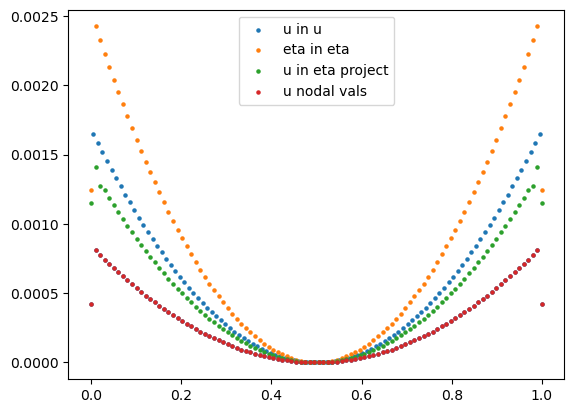

In [ ]:
import matplotlib.pyplot as plt
s=5
plt.scatter(u_basis.doflocs.T, tester_u, s=s, label="u in u")
plt.scatter(eta_basis.doflocs.T, tester_eta, s=s, label="eta in eta")
# plt.scatter(eta_basis.doflocs.T, convert_u_basis_to_ordered1(tester_u), s=s, label="u in eta manual 1")
# plt.scatter(eta_basis.doflocs.T, convert_u_basis_to_ordered2(tester_u), s=s, label="u in eta manual 2") 
plt.scatter(eta_basis.doflocs.T, eta_basis.project(u_basis.interpolate(tester_u)), s=s, label='u in eta project')
plt.scatter(eta_basis.doflocs.T, tester_u[:len(eta_basis.doflocs.T)], s=s, label='u nodal vals')
plt.scatter(x_coordinates, quad(x_coordinates), s=s, label='True?')
plt.legend()

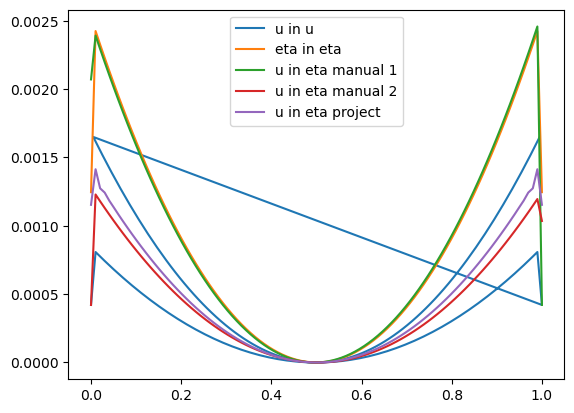

In [5]:
import matplotlib.pyplot as plt
s=5
plt.plot(u_basis.doflocs.T, tester_u, label="u in u")
plt.plot(eta_basis.doflocs.T, tester_eta, label="eta in eta")
plt.plot(eta_basis.doflocs.T, convert_u_basis_to_ordered1(tester_u), label="u in eta manual 1")
plt.plot(eta_basis.doflocs.T, convert_u_basis_to_ordered2(tester_u),label="u in eta manual 2") 
plt.plot(eta_basis.doflocs.T, eta_basis.project(u_basis.interpolate(tester_u)), label='u in eta project')
plt.legend()

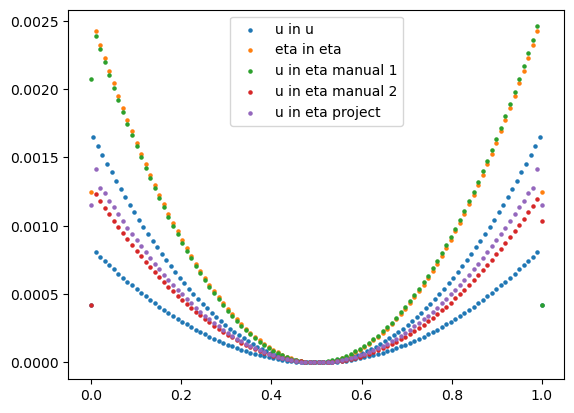

In [6]:
import matplotlib.pyplot as plt
s=5
plt.scatter(u_basis.doflocs.T, tester_u, s=s, label="u in u")
plt.scatter(eta_basis.doflocs.T, tester_eta, s=s, label="eta in eta")
plt.scatter(eta_basis.doflocs.T, convert_u_basis_to_ordered1(tester_u), s=s, label="u in eta manual 1")
plt.scatter(eta_basis.doflocs.T, convert_u_basis_to_ordered2(tester_u), s=s, label="u in eta manual 2") 
plt.scatter(eta_basis.doflocs.T, eta_basis.project(u_basis.interpolate(tester_u)), s=s, label='u in eta project')
plt.legend()

In [30]:
def eff(x):
    return (2**x + 1)/3

In [44]:
print(str(eff(11)), "\n")

683.0 



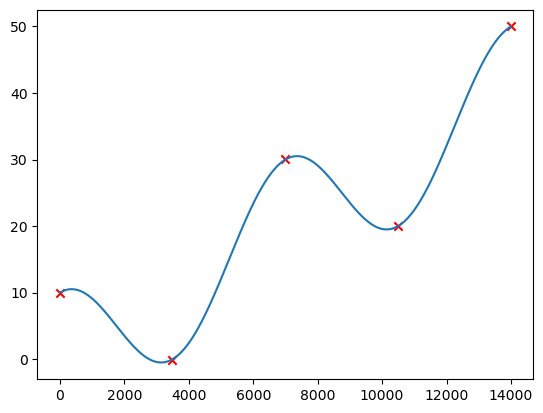

In [100]:
L = 14000

import numpy as np
import matplotlib.pyplot as plt

def topography(x):
    # return H_BAR - 5*(1+np.tanh((x-S)/2000))
    return (40*x)/L - 10*np.sin(np.pi*((4*x/L) - 0.5)) #vasquez
    #return 50.5 - (40*x)/L - 10*np.sin(np.pi*((4*x/L) - 0.5)) #vasquez

x_coord = np.linspace(0, 14000, 1000)
y_vals = topography(x_coord)

num_sensors = 5
sensor_error = 0.1

sensor_locations_indices = np.linspace(0, len(x_coord)-1, num_sensors, dtype=int)
sensor_locations = x_coord[sensor_locations_indices]
uncertainty_matrix = (sensor_error**2) * np.eye(len(sensor_locations))
uncertainty_matrix[0,:] = uncertainty_matrix[:,0] = uncertainty_matrix[-1,:] = uncertainty_matrix[:,-1] = np.zeros_like(uncertainty_matrix[:,-1])
sensor_error_vector = np.random.multivariate_normal(np.zeros_like(sensor_locations), uncertainty_matrix)
sensor_readouts = y_vals[sensor_locations_indices] + sensor_error_vector

plt.plot(x_coord, y_vals)
plt.scatter(sensor_locations, sensor_readouts, marker='x', color='red')


In [104]:
import stattools as st

prior_mean = np.linspace(10, 50, len(x_coord))
prior_at_test = prior_mean[sensor_locations_indices]

def subselect_from_y2(x_1, x_2, y_2):
    """Selects values from y_2 based on where x_1 values appear in x_2.

    Args:
        x_1 (numpy.ndarray): Array of coordinate values.
        x_2 (numpy.ndarray): Reference coordinate values.
        y_2 (numpy.ndarray): Values corresponding to x_2.

    Returns:
        numpy.ndarray: Selected values from y_2 corresponding to x_1 indices in x_2.
    """
    indices = np.searchsorted(x_2, x_1)
    valid = (indices < len(x_2)) & (x_2[indices] == x_1)
    return y_2[indices[valid]]

def ml_interpolate(training_space, training_values, test_space, training_error_matrix=False, prior_test_mean=False, prior_test_cov=False, method='gpr', kernel='matern', params=(10, 5000)):
    input_space = np.reshape(training_space, (len(training_space),1))
    output_space = np.reshape(test_space, (len(test_space),1))

    if prior_test_mean is not False:
        prior_test_mean_at_training_locations = subselect_from_y2(training_space, test_space, prior_test_mean)

    if method=='gpr':
        rho = params[0]
        ell = params[1]
        K_star_star_diff = st.build_dif_x(output_space)
        K_star_diff = st.build_dif_x(output_space, input_space)
        K_diff = st.build_dif_x(input_space)
        match kernel:
            case 'matern':
                if training_error_matrix is not False:
                    covariance_matrix = training_error_matrix + np.reshape(st.third_dif_matern(K_diff, rho, ell), (len(input_space), len(input_space)))
                else:
                    covariance_matrix = np.reshape(st.third_dif_matern(K_diff, rho, ell), (len(input_space), len(input_space)))
                covariance_star_matrix = np.reshape(st.third_dif_matern(K_star_diff, rho, ell), (len(input_space), len(output_space)))
                if prior_test_cov is not False:
                    covariance_star_star_matrix = prior_test_cov
                else:
                    covariance_star_star_matrix = np.reshape(st.third_dif_matern(K_star_star_diff, rho, ell), (len(output_space), len(output_space)))
        
        if prior_test_mean is not False:
            posterior_mean = prior_test_mean + covariance_star_matrix.T @ np.linalg.inv(covariance_matrix) @ (training_values - prior_test_mean_at_training_locations)
        else:
            posterior_mean = covariance_star_matrix.T @ np.linalg.inv(covariance_matrix) @ (training_values)
        posterior_covariance = covariance_star_star_matrix - covariance_star_matrix.T @ np.linalg.inv(covariance_matrix) @ covariance_star_matrix

    return posterior_mean, posterior_covariance

post_mean, post_cov = ml_interpolate(sensor_locations, sensor_readouts, x_coord, training_error_matrix=uncertainty_matrix, prior_test_mean=prior_mean)
uncertainty_matrix = 5*np.eye(len(sensor_locations))
post_mean, post_cov = ml_interpolate(sensor_locations, np.asarray([10., 20., 30., 40., 50.]), np.reshape(x_coord, (len(x_coord),1)), training_error_matrix=uncertainty_matrix,)

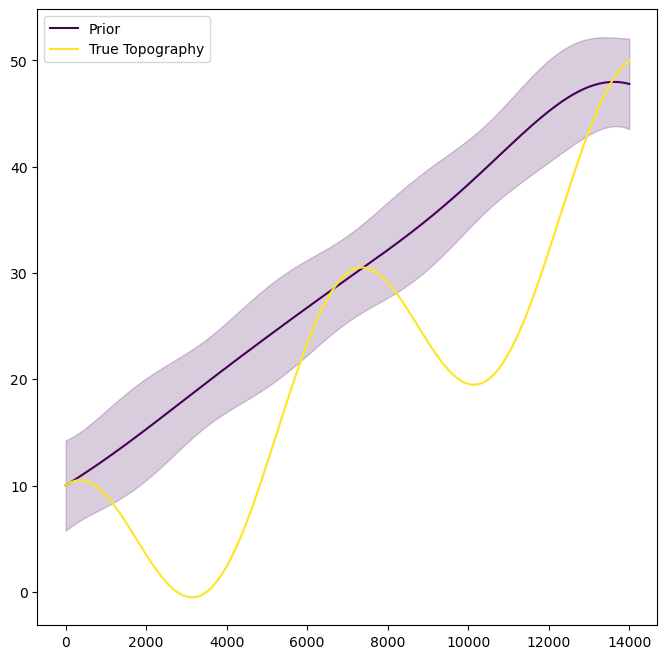

In [105]:
vt.plot_time_series_with_error_bars([post_mean, y_vals], [np.diag(post_cov), np.zeros(len(y_vals))], x_coord, labels=['Prior','True Topography'])

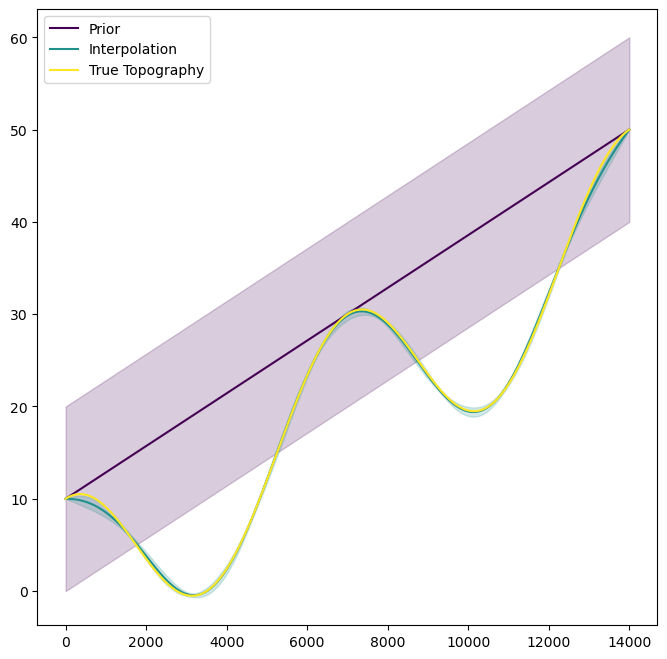

In [91]:
import visualtools as vt
prior_cov = np.reshape(st.third_dif_matern(st.build_dif_x(np.reshape(x_coord, (len(x_coord),1))), 5, 5000), (len(x_coord), len(x_coord)))

vt.plot_time_series_with_error_bars([prior_mean, post_mean, y_vals], [np.diag(prior_cov), np.diag(post_cov), np.zeros(len(y_vals))], x_coord, labels=['Prior', 'Interpolation', 'True Topography'])

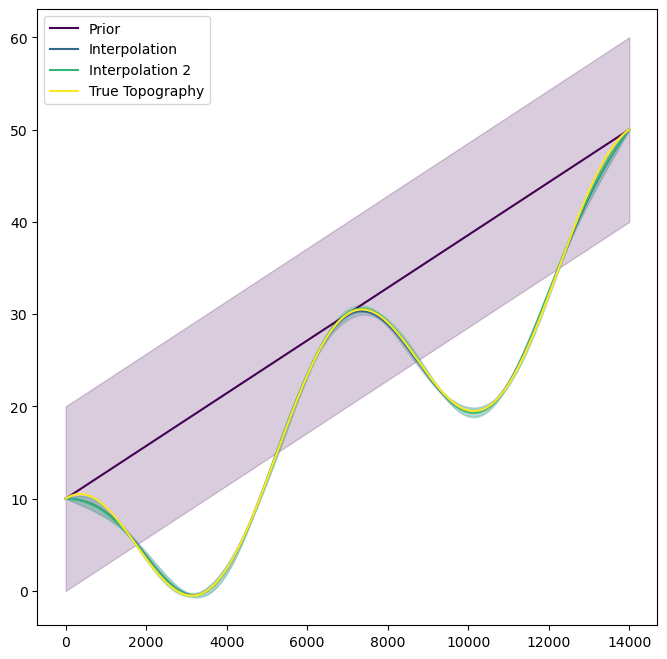

In [92]:
sensor_locations_indices = np.linspace(0, len(x_coord)-1, num_sensors, dtype=int)
sensor_locations = x_coord[sensor_locations_indices]
uncertainty_matrix = (sensor_error**2) * np.eye(len(sensor_locations))
uncertainty_matrix[0,:] = uncertainty_matrix[:,0] = uncertainty_matrix[-1,:] = uncertainty_matrix[:,-1] = np.zeros_like(uncertainty_matrix[:,-1])
sensor_error_vector = np.random.multivariate_normal(np.zeros_like(sensor_locations), uncertainty_matrix)
sensor_readouts = y_vals[sensor_locations_indices] + sensor_error_vector

post_mean2, post_cov2 = ml_interpolate(sensor_locations, sensor_readouts, x_coord, training_error_matrix=uncertainty_matrix, prior_test_mean=post_mean)
import visualtools as vt

vt.plot_time_series_with_error_bars([prior_mean, post_mean, post_mean2, y_vals], [np.diag(prior_cov), np.diag(post_cov), np.diag(post_cov2), np.zeros(len(y_vals))], x_coord, labels=['Prior', 'Interpolation', 'Interpolation 2', 'True Topography'])

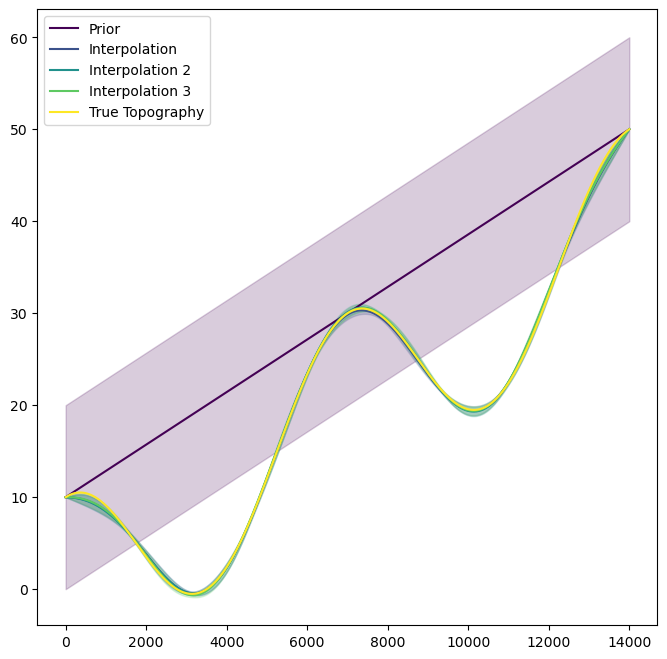

In [93]:
sensor_locations_indices = np.linspace(0, len(x_coord)-1, num_sensors, dtype=int)
sensor_locations = x_coord[sensor_locations_indices]
uncertainty_matrix = (sensor_error**2) * np.eye(len(sensor_locations))
uncertainty_matrix[0,:] = uncertainty_matrix[:,0] = uncertainty_matrix[-1,:] = uncertainty_matrix[:,-1] = np.zeros_like(uncertainty_matrix[:,-1])
sensor_error_vector = np.random.multivariate_normal(np.zeros_like(sensor_locations), uncertainty_matrix)
sensor_readouts = y_vals[sensor_locations_indices] + sensor_error_vector

post_mean3, post_cov3 = ml_interpolate(sensor_locations, sensor_readouts, x_coord, training_error_matrix=uncertainty_matrix, prior_test_mean=post_mean)
import visualtools as vt

vt.plot_time_series_with_error_bars([prior_mean, post_mean, post_mean2, post_mean3,y_vals], [np.diag(prior_cov), np.diag(post_cov), np.diag(post_cov2), np.diag(post_cov3), np.zeros(len(y_vals))], x_coord, labels=['Prior', 'Interpolation', 'Interpolation 2', 'Interpolation 3','True Topography'])

In [97]:
np.linspace(10, 50, 5)

array([10., 20., 30., 40., 50.])